## Practice Lab : Polynomial Regression

What if your data is more complex than a straight line? Surprisingly, you can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression.

There are two factors when determining model performance: overfitting and underfitting. Overfitting is when the model is too complex and does well on the training data but not on the test data. Underfitting is when the model is too simple and performs poorly on the training and testing data sets.

Overfitting is simple to deal with, using methods like regularization, which we will discuss in the next lab. To deal with underfitting, we can build a more complex model using methods like polynomial regression. If making a more complex model does not work, this may involve using more data to train the model on or obtaining new features. As this process is complex, it's better to determine if the model can overfit the data first. Therefore, in this section, we will use Polynomial Regression to overfit the data to determine if we have an adequate amount of data.

In this notebook, we will explore Polynomial Regression and perform polynomial transform using individual features as well as multiple features.

### Objectives

After completing this lab you will be able to:

*   Understand the concept of  overfitting versus underfitting
*   Apply polynomial transforms to data
*   Perform  hyperparameters grid search on a model, using validation data

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import load_digits, load_wine
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

sns.set_context('notebook')
sns.set_style('white')


In [110]:
# This function will calculate the R-square on each feature given the a input model.
def get_R2_features(model,test=True): 
    #X: global  
    features=list(X)
    # features.remove("three")
    
    R_2_train=[]
    R_2_test=[]

    for feature in features:
        model.fit(X_train[[feature]],y_train)
        
        R_2_test.append(model.score(X_test[[feature]],y_test))
        R_2_train.append(model.score(X_train[[feature]],y_train))
        
    plt.bar(features,R_2_train,label="Train")
    plt.bar(features,R_2_test,label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()
    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )


# This function will plot the distribution of two inputs.
def  plot_dis(y,yhat):    
    plt.figure()
    ax1 = sns.kdeplot(y, color="r", label="Actual Value")
    sns.kdeplot(yhat, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()


### **Reading and understanding our data**

For this lab, we will be using the car sales dataset, hosted on IBM Cloud object storage. The dataset contains all the information about cars, the name of the manufacturer, the year it was launched, all car technical parameters, and the sale price. This dataset has already been pre-cleaned and encoded (using one-hot and label encoders) in the Linear Regression Notebook.

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/encoded_car_data.csv'

In [111]:
data = pd.read_csv('data/encoded_car_data.csv')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight        205 no

Before we begin our polynomial analysis, let's visualize some of the relationships between our features and the target variable, 'price'.

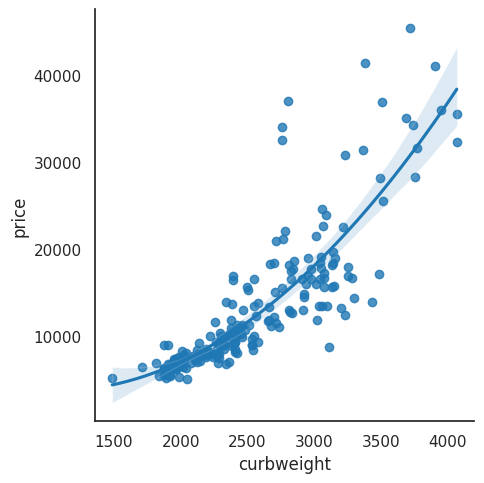

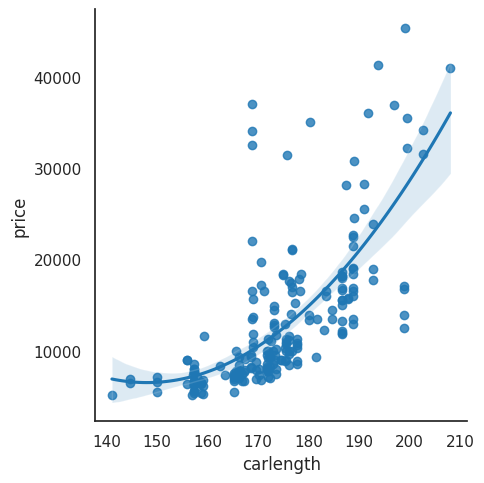

In [112]:
sns.lmplot(x = 'curbweight', y = 'price', data = data, order=2)
sns.lmplot(x = 'carlength', y = 'price', data = data, order=2)

The relationship is more curved.

### Exercise 1

In this Exercise, visualize the relationship between the 'horsepower' and the target variable, 'price'.

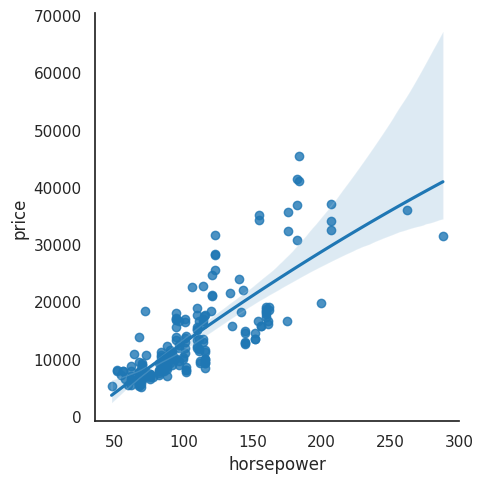

In [113]:
sns.lmplot(x = 'horsepower', y = 'price', data = data, order=2)

<BR>

___

### **Side Notes on Seaborn lmplot()**

`sns.lmplot()` is essentially a "shortcut" that combines three steps into one single line of code:

1. The Scatter Plot: It plots the raw data points (x and y).

2. The Transformation: If order=2, it internally calculates the polynomial features (it squares the x values, just like you would do with PolynomialFeatures in Scikit-Learn).

3. The Regression: It fits a Linear Regression model to those features and draws the resulting curve.

It is specifically designed to help you visualize the relationship between two variables—in your case, how the carlength affects the price of a car. 

**Why use this instead of Scikit-Learn?**

* It’s mostly for Exploratory Data Analysis (EDA).

    * The Scikit-Learn Way: You have to transform the data, fit the model, generate a range of test points, predict the values, and then plot them using Matplotlib. This is great for building a model you intend to use.

    * The Seaborn Way: You just want to "see" if the relationship looks quadratic or linear before you spend time coding a complex model.

<BR>

`sns.lmplot()` acts as a "sanity check" to see if a feature actually has a relationship with your target before you throw it into a complex model.

However, there is a subtle distinction between Correlation (how the dots move) and Importance (how much the model relies on it). Here is how to use lmplot to judge a feature:
1. Identifying "Linearity"

* If you use the default order=1 and the line passes through the center of the clusters with a steep slope, that feature is a strong linear predictor.

    * High Importance: A steep slope (up or down).

    * Low Importance: A flat horizontal line (meaning as carlength changes, price stays the same).

2. Identifying "Non-Linear" Importance (The order=2 trick)

* This is where you are right now. If a straight line (order=1) looks terrible, but a curved line (order=2) fits the dots beautifully, you’ve discovered that the feature is important, but only if you transform it first.

    * If you only used a basic Linear Regression, the model might think carlength is "weak."

    * By seeing the curve in lmplot, you know you should use PolynomialFeatures in Scikit-Learn to "unlock" that feature's true importance.

3. The "Noise" Check

* Look at the shadow (the translucent band) around the line in your lmplot. This is the 95% Confidence Interval.

    * Tight Shadow: The model is very "sure" about the relationship. High importance/reliability.

    * Wide/Flaring Shadow: The data is too messy or sparse. Even if there's a slope, the model might struggle to use this feature effectively.

4. What lmplot CAN'T tell you

* While it's great for visual verification, it has one major limitation: it only looks at one feature at a time.

* In your Ames Housing or Car Price models, features often work in "teams."

    * A feature might look unimportant on an lmplot by itself.

    * But when combined with another feature (like engine_size + carlength), it might suddenly become very important.

<BR>

**Summary: Useful Workflow**

1. **sns.lmplot (Order 1)**: Is there a straight-line trend?

2. **sns.lmplot (Order 2)**: Does a curve fit better? (If yes, use PolynomialFeatures).

3. **df.corr()**: Check the actual math (Correlation coefficient).

4. **model.coef_**: After training your Scikit-Learn model, check the actual weights to see what the "brain" of the AI decided was most important.

<BR>

___

<BR>

### Data Preparation

Let's first split our data into `X` features and `y` target.

In [114]:
X = data.drop('price', axis=1)
y = data.price

### Train Test Split

Now, we split our data, using <code>train_test_split</code> function, into the training and testing sets, allocating 30% of the data for testing.

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])

Number of test samples: 62
Number of training samples: 143


### Multiple Features

Let's create a LinearRegression object, lm, and fit the model with multiple features with our X_train and y_train data. We then call predict with the testing data set and calculate the R-square score on both training and test datasets.

In [116]:
lm = LinearRegression()
lm.fit(X_train, y_train)
predicted = lm.predict(X_test)

print("R^2 on training data: ",lm.score(X_train, y_train))
print("R^2 on testing data : ",lm.score(X_test, y_test))

R^2 on training data:  0.9262722224294516
R^2 on testing data :  0.8471124710243334


We can plot distributions of the predicted values versus the actual values.


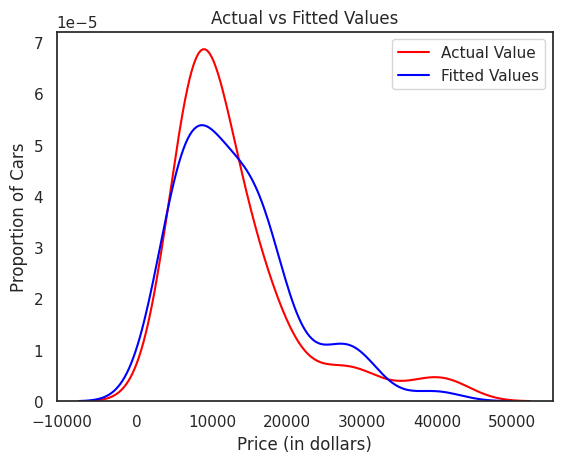

In [117]:
plot_dis(y_test, predicted)

Below, we will view the estimated coefficients for the linear regression problem.

In [118]:
{col:coef for col, coef in zip(X.columns, lm.coef_)}

{'diesel': np.float64(771.2244282090302),
 'gas': np.float64(-771.224428205094),
 'std': np.float64(304.3744402511874),
 'turbo': np.float64(-304.3744402510732),
 'convertible': np.float64(1786.647521855913),
 'hardtop': np.float64(3165.452040209071),
 'hatchback': np.float64(-1770.7658370331858),
 'sedan': np.float64(-687.6843494280745),
 'wagon': np.float64(-2493.6493756037094),
 '4wd': np.float64(-605.6774561363832),
 'fwd': np.float64(-270.9879508471072),
 'rwd': np.float64(876.665406983499),
 'dohc': np.float64(2467.0217490605596),
 'dohcv': np.float64(-13286.459963163768),
 'l': np.float64(2148.236615121714),
 'ohc': np.float64(4642.4285008526),
 'ohcf': np.float64(6068.751775202578),
 'ohcv': np.float64(-2819.9527705637856),
 'rotor': np.float64(779.9740934900934),
 'eight': np.float64(9218.442191802074),
 'five': np.float64(-2742.728535000297),
 'four': np.float64(-5338.369710810963),
 'six': np.float64(-2146.2003214469246),
 'three': np.float64(-9.094947017729282e-13),
 'twelv

We can plot the coefficients as a bar chart shown below.

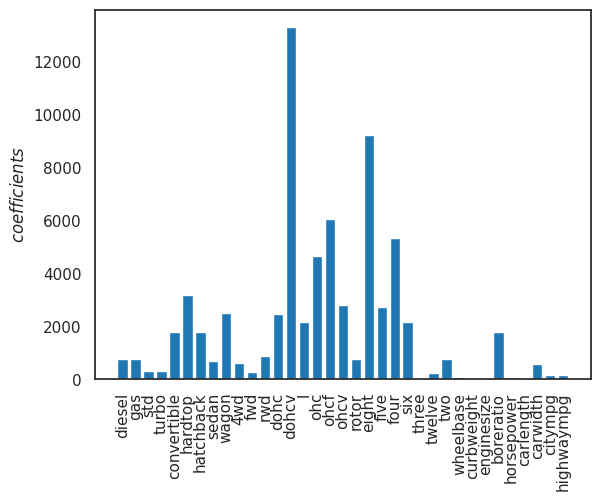

In [119]:
plt.bar(X.columns,abs(lm.coef_))
plt.xticks(rotation=90)
plt.ylabel("$coefficients$")
plt.show()

Usually, we can interpret the lager coefficients as having more importance on the prediction, but this is not always the case, so let's look at the individual features.

<BR>

___

#### **Additional Notes:**

As it is, the coefficients values may not indicate its importance on the prediction. This is because each feature's unit is different. To make this consistent, we need to scale the features unit. Once you have scaled your data (using StandardScaler or MinMaxScaler), you have removed the "units" problem (meters vs. kilometers). On this level playing field, the coefficients (β) directly represent the relative impact of each feature on the model's prediction.

1. How to interpret the "Impact"

    * When the data is scaled, you can look at the coefficients in two ways:

        * Magnitude (The "Strength"): The larger the absolute value ∣β∣, the more the model relies on that feature to move the price.

            * Example: If carlength has a coefficient of 0.8 and door_count has a coefficient of 0.05, carlength is significantly more "important" to the model.

        * Direction (The "Relationship"): * Positive (+): As this feature increases, the predicted price goes up.

            * Negative (−): As this feature increases, the predicted price goes down (e.g., mileage or age).


2. The Best Way to List Them

    * Instead of just a dictionary, it is usually better to create a sorted DataFrame. This makes it immediately obvious which features are the "heavy hitters." See codes below:



In [120]:
# Create a DataFrame of features and their coefficients
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lm.coef_
})

# Add a column for the absolute value (actual impact)
importance_df['Abs_Impact'] = importance_df['Coefficient'].abs()

# Sort by impact
importance_df = importance_df.sort_values(by='Abs_Impact', ascending=False)

print(importance_df)

        Feature   Coefficient    Abs_Impact
13        dohcv -1.328646e+04  1.328646e+04
19        eight  9.218442e+03  9.218442e+03
16         ohcf  6.068752e+03  6.068752e+03
21         four -5.338370e+03  5.338370e+03
15          ohc  4.642429e+03  4.642429e+03
5       hardtop  3.165452e+03  3.165452e+03
17         ohcv -2.819953e+03  2.819953e+03
20         five -2.742729e+03  2.742729e+03
8         wagon -2.493649e+03  2.493649e+03
12         dohc  2.467022e+03  2.467022e+03
14            l  2.148237e+03  2.148237e+03
22          six -2.146200e+03  2.146200e+03
4   convertible  1.786648e+03  1.786648e+03
29    boreratio -1.781280e+03  1.781280e+03
6     hatchback -1.770766e+03  1.770766e+03
11          rwd  8.766654e+02  8.766654e+02
25          two  7.799741e+02  7.799741e+02
18        rotor  7.799741e+02  7.799741e+02
0        diesel  7.712244e+02  7.712244e+02
1           gas -7.712244e+02  7.712244e+02
7         sedan -6.876843e+02  6.876843e+02
9           4wd -6.056775e+02  6

<BR>

___

<BR>

### Individual Features

We can train the model and plot our $R^2$ for each of the features on the training and testing data sets, using the function <code>get_R2\_features</code>.

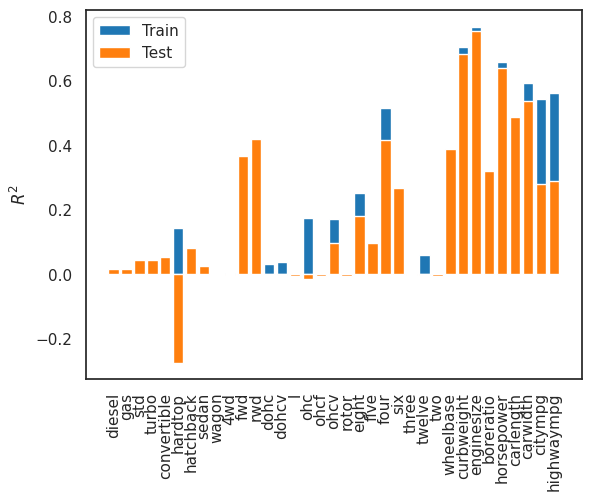

Training R^2 mean value 0.21194408471824258 Testing R^2 mean value 0.177124767371776 
Training R^2 max value 0.7686929078033781 Testing R^2 max value 0.7534902447506853 


In [121]:
get_R2_features(lm)

From the above plot, we see that some individual features perform similarly to  using all the features, in  addition, we see that smaller coefficients seem to correspond to a larger $R^{2}$, therefore  larger coefficients correspond to overfiting.

Say if we fit the model with one feature at a time and track its corresponding R-square error (as illustrated above), should we expect a smaller coefficient result in larger R-square ? 

The answer is actually no. There is no mathematical relationship between the size of a coefficient and the R2 (R-squared) value.

In fact, you can have a massive coefficient with a terrible R2, or a tiny coefficient with a perfect R2. Here is why they measure two completely different things:

1. The Difference in "Job Description"

    * Coefficient (β): Measures Scale/Slope. It tells you how much the price changes for every 1 unit of the feature.

    * R2: Measures Certainty/Fit. It tells you how well the dots follow the line, regardless of whether that line is steep or flat.

2. Scenario A: The "Big Slope, Big Mess"

    * Imagine you are predicting car prices based on Engine Displacement (Liters).

        * The coefficient might be +5,000 (meaning for every extra liter, the price jumps by 5,000).

        * However, if the data points are scattered all over the place (some 2L cars are cheap, some are expensive), the R2 will be low (e.g., 0.2).

        * Result: A large coefficient, but a bad fit.

3. Scenario B: The "Small Slope, Perfect Fit"

    * Imagine you are predicting car prices based on a fixed government tax that is exactly 0.01 per dollar of the car's length.

        * The coefficient is tiny (0.01).

        * But because the tax is a strict rule, every single data point falls exactly on the line. The R2 will be 1.0 (Perfect).

        * Result: A tiny coefficient, but a perfect fit.


**Why R2 is usually what you want for "Importance"**

* If you are testing features one by one to see which is the "best" predictor, you should focus on R2, not the coefficient.

    * Higher R2 means that feature "explains" the variance in price better. It is a more reliable "signal."

    * Higher Coefficient (on scaled data) only tells you that the feature has a large "leverage" on the final number, but it doesn't tell you if the model is actually accurate.


**Summary:**

|Metric	|What it tells you	|Does "Larger" mean "Better"?|
|---|---|---|
|Coefficient	|The "Weight" or "Slope"	|No. It just tells you the rate of change.|
|R2	|The "Accuracy" or "Fit"	|Yes. It tells you how much of the "story" that feature explains.|



### Exercise 2

In this Exercise, calculate the $R^2$ using the object Pipeline for  Linear Regression and apply `StandardScaler()` to all features, then use the function `plot_dis` to compare the predicted values versus the actual values.

R^2 on training data  0.9262722224294516
R^2 on testing data  0.8419174509630336


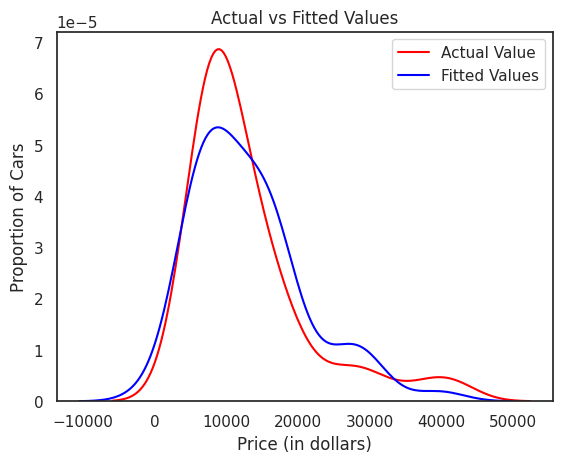

In [122]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train, y_train)
print("R^2 on training data ", pipe.score(X_train, y_train))
print("R^2 on testing data ",  pipe.score(X_test,y_test))

predicted = pipe.predict(X_test)
plot_dis(y_test, predicted)

### Exercise 3

In this Exercise, calculate the $R^2$ using the object Pipeline with  `StandardScaler()` for each individual features using the function `get_R2_features`.

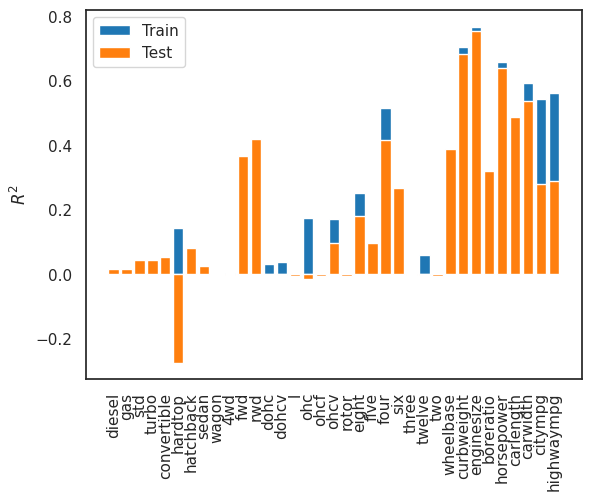

Training R^2 mean value 0.2119440847182426 Testing R^2 mean value 0.17712476737177596 
Training R^2 max value 0.7686929078033782 Testing R^2 max value 0.7534902447506853 


In [123]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
get_R2_features(pipe)

The above chart shows us that the R-square error for each feature is exactly the same value regardless if the model is fitted with scaled or unscaled features. This is an important property of Linear Regression: it is **scale-invariant**. In addition, the prediction result will also be the same, along with the P-value. What changed are the coefficients, the intercept, and the training speed (Scaling makes the model converge faster).

If you are just doing a basic "One Feature vs. Price" test to see which feature is the most accurate, scaling is optional because the R2 will tell you the same truth regardless. But as soon as you move to a multi-feature model with Regularization, scaling becomes a mandatory step in your pipeline!

<BR>

### Polynomial Features

#### Multiple Features

Polynomial transform is a simple way to increase the complexity of the model, but we must be mindful of overfitting.
Below, we will perform a second degree (degree=2) polynomial transformation.

In [124]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# transforming the training and testing datasets
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

**What does `include_bias=False` do?**

When you create polynomial features, the mathematical formula for a 2nd-degree polynomial is:
        y=β0​(1)+β1​(x)+β2​(x2)

    If include_bias=True (Default): Scikit-Learn adds a column of all 1s to your data. This represents the intercept (β0​).

    If include_bias=False: Scikit-Learn does not add that column of 1s.

Why set it to False?
In almost all cases, you are going to feed these features into a LinearRegression() model next. The LinearRegression model in Scikit-Learn already has an intercept built-in by default (fit_intercept=True).

If you leave include_bias=True, you end up with two "intercept" columns fighting each other, which is redundant and can occasionally cause minor numerical issues. Setting it to False keeps your feature matrix cleaner.

<BR>

**Why fit_transform on Train, but only transform on Test?**

This is the "Golden Rule" of Machine Learning: Never let your model see the future.

* fit(): This is where the transformer "learns" the rules. For PolynomialFeatures, it learns which columns exist and how to square them. For StandardScaler, it learns the Mean and Standard Deviation.

* transform(): This is where the transformer actually does the math to change the numbers.

<BR>

_The "Data Leakage" Problem_

If you used fit_transform() on your Test set, you would be calculating a new Mean or a new set of rules based on the test data.

In a real-world scenario, your model is a "black box" that has already been trained. When a new car (test data) comes in, the model must treat it exactly how it treated the training data.

* Fit on Train: "I have learned that the average car length is 4500mm."

* Transform Train: "I will scale everything based on that 4500mm average."

* Transform Test: "I will scale this new car based on the Train average (4500mm), not its own average."

<BR>

**Note that the fitting in PolynomialFeatures does very different task from the fitting in the model:**

* In PolynomialFeatures, you are just defining the shape of the data. No "learning" of the relationship between car length and price happens here. It is purely structural.

* In the Model, the actual "Artificial Intelligence" happens. The model looks at the columns created in PolynomialFeatures and tries to find the patterns.

<BR>

`X_train_poly` and `X_test_poly` now contain the original features of X plus the square of these features and the cross-terms combination.
Let's check the shape of the newly created train and test sets.

In [125]:
print(X_train_poly.shape)
print(X_test_poly.shape)

(143, 665)
(62, 665)


In [126]:
# Now, we fit the model with the newly created features
lm = LinearRegression()
lm.fit(X_train_poly, y_train)

# making predictions
predicted = lm.predict(X_train_poly)

# check R-square scores on training and test datasets
print("R^2 on training data:", lm.score(X_train_poly, y_train))
print("R^2 on testing data:", lm.score(X_test_poly,y_test))

R^2 on training data: 0.9985318497975831
R^2 on testing data: -36729.95791041275


We see the model has a negative $R^{2}$ on the test data set, this is sign of **overfiting**.

### Individual Features

<p>Data Pipelines simplify the steps of processing the data. We use the module <code>Pipeline</code> to create a pipeline. We also use <code>PolynomialFeatures</code> as a step in our pipeline.</p>

In [127]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model', LinearRegression())]

pipe=Pipeline(Input)
pipe.fit(X_train, y_train)

print("R^2 on training  data:", pipe.score(X_train, y_train))
print("R^2 on testing data:", pipe.score(X_test,y_test))

R^2 on training  data: 0.9985318497975831
R^2 on testing data: -36729.95791041275


We can see the results are identical.

We can train our model on each of the features using the Polynomial Feature transform of the second degree. Then we can plot our $R^2$.

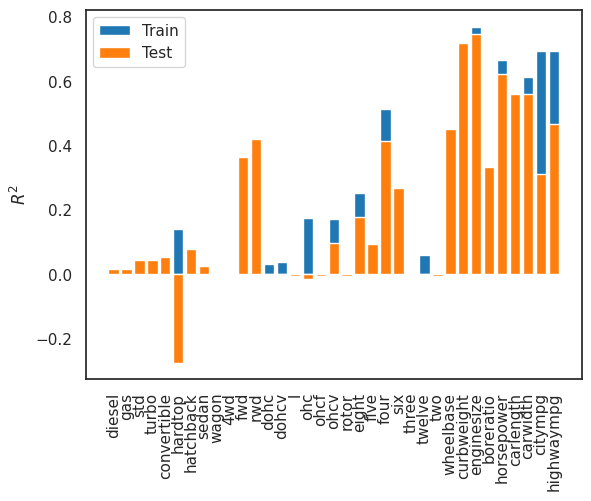

Training R^2 mean value 0.22424595021684546 Testing R^2 mean value 0.1882453143478279 
Training R^2 max value 0.7706959974452947 Testing R^2 max value 0.7463370080614307 


In [128]:
get_R2_features(pipe)

Feature with the max $R^{2}$ is higher than when using all the features.

### GridSearch and  Pipeline

In this section of the notebook, we will define a pipeline object, then use GridSearch to find the best hyper-parameters of the model by using  cross-validation method of the  parameter grid, as shown in the figure below. A 5-fold cross validation is used by default. We will learn more about k-fold cross validation in the next, Cross Validation lesson of the Course.

<center>
    <img src="data/k-fold.png">
</center>
<center>source scikit-learn.org</center>

We create `PolynomialFeatures()` pipeline.

In [129]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('scaler', StandardScaler()),('model',LinearRegression() )]
pipe=Pipeline(Input)

To search for the best combination of hyperparameters, we create a  <b>GridSearchCV</b> object with dictionary of parameter values. The parameters of pipelines can be set using the name of the key separated by
'\__', then the parameter name of the key.

In [130]:
param_grid = {
    "polynomial__degree": [1, 2, 3],
   
}

<b>polynomial\_\_degree</b>: is the degree of the polynomial.

In [131]:
search = GridSearchCV(pipe, param_grid, n_jobs=1)

pipe.fit(X_train, y_train)

search.fit(X_test, y_test)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

The object finds the best parameter values on the validation data. We can obtain the estimator with the best parameters and assign it to the variable `best`, as follows:

In [132]:
best = search.best_estimator_
best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Now, we test our model on the test data to see the best score.

In [133]:
best.score(X_test,y_test)

0.9681812255199611

Finally, we can plot a distribution of the predicted values versus the actual values.

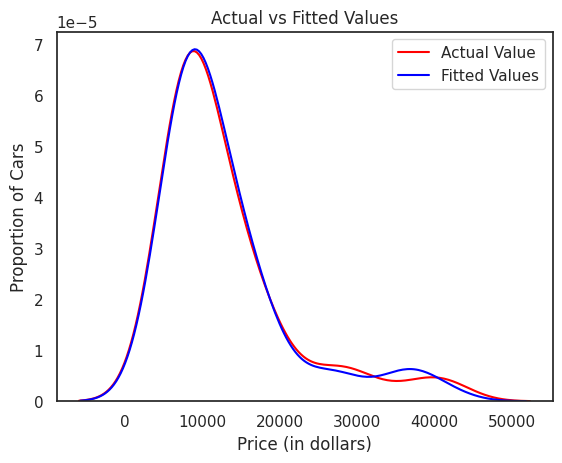

In [134]:
predicted = best.predict(X_test)
plot_dis(y_test,predicted)

As shown, the result is almost perfect!

### Exercise 4

In this Exercise, calculate the $R^2$ using the object `Pipeline` with `GridSearch` for each individual features.

Training R^2 mean value 0.22564074978401708 Testing R^2 mean value 0.18763756977897997
Training R^2 max  value 0.7871440212620879  Testing R^2 max  value 0.7978026239432321



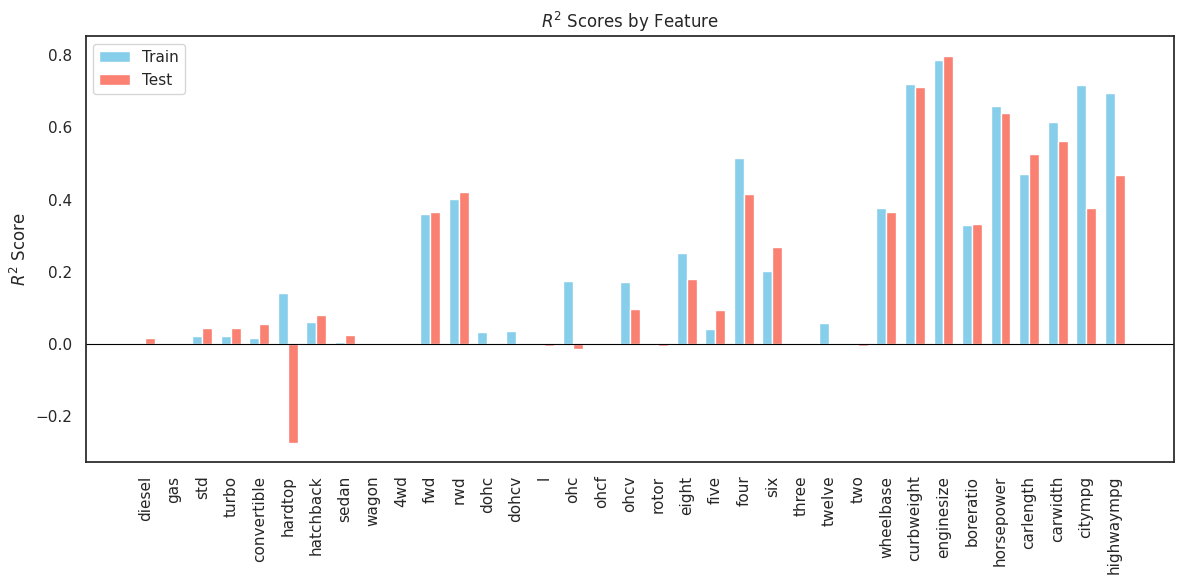

In [135]:
features=list(X)

R_2_train=[]
R_2_test=[]

for feature in features:
    param_grid = {
        "polynomial__degree": [1,2,3],
        "model__positive": [True, False]
    }

    Input = [ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression()) ]
    pipe = Pipeline(Input)

    search = GridSearchCV(pipe, param_grid, n_jobs=-1) # n_jobs specify number of CPU core to use for processing (-1 = use all available core)
    search.fit(X_train[[feature]], y_train)
    best = search.best_estimator_

    # print(f"Feature: {feature:13} - {search.best_params_}")
    # print(f"Feature: {feature:13} - R_2_train: {best.score(X_train[[feature]],y_train):.4f}, R_2_test: {best.score(X_test[[feature]],y_test):.4f}")

    R_2_train.append(best.score(X_train[[feature]],y_train))
    R_2_test.append(best.score(X_test[[feature]],y_test))


print(f"Training R^2 mean value {str(np.mean(R_2_train))} Testing R^2 mean value {str(np.mean(R_2_test))}")
print(f"Training R^2 max  value {str(np.max(R_2_train))}  Testing R^2 max  value {str(np.max(R_2_test))}\n")



## Plot the R-square Scores side by side
# 1. Setup positions
x = np.arange(len(features))  # The label locations [0, 1, 2...]
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# 2. Plot bars with offsets
# We subtract half the width from x for Train, and add it for Test
rects1 = ax.bar(x - width/2, R_2_train, width, label='Train', color='skyblue')
rects2 = ax.bar(x + width/2, R_2_test, width, label='Test', color='salmon')

# 3. Clean up the labels
ax.set_ylabel('$R^2$ Score')
ax.set_title('$R^2$ Scores by Feature')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=90)
ax.legend()

# Optional: Add a horizontal line at 0 for clarity
ax.axhline(0, color='black', linewidth=0.8)

fig.tight_layout()
plt.show()

<BR>

___

#### **Additional Notes on the above**

**What is `GridSearchCV()`, and how is it used with `Pipeline()` ?**

Think of Pipeline as the "Assembly Line" and GridSearchCV as the "Quality Control Manager" who tests every possible machine setting to find the perfect configuration.

GridSearchCV (Grid Search Cross-Validation) is an automated tool used for Hyperparameter Tuning.

In machine learning, "Parameters" are what the model learns from data (like coefficients), but "Hyperparameters" are the settings you choose before training starts (like the degree in PolynomialFeatures or alpha in Ridge).
* Grid Search: You give it a "grid" (a list) of values to try.
* Cross-Validation: It doesn't just test once; it splits your data into multiple "folds" (usually 5) to make sure the results aren't just a lucky fluke.

While you can use GridSearchCV on a single model, it becomes incredibly powerful when combined with a Pipeline.

When you put a Pipeline inside GridSearchCV, you aren't just tuning the model; you are tuning the entire workflow. This allows you to ask the computer questions like:
* "Is it better to use a Degree 2 or Degree 3 polynomial?"
* "Should I use a Ridge model or a Lasso model?"
* "What is the best penalty value (alpha) for my model?"

There are two massive benefits to this relationship:
* **Prevents Data Leakage**: Because GridSearchCV handles the Pipeline, it ensures that the scaling/transformation happens inside the cross-validation folds. This means the model never "accidentally" sees the validation data during the fitting process.
* **Simplicity**: You don't have to write nested for loops to test different combinations of degrees and alphas. GridSearchCV handles the combinations (in the example above, it would test 3×3=9 different versions of your model).

_A Practical Example_
```python
    from sklearn.model_selection import GridSearchCV
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import Ridge

    # 1. Build the Assembly Line (Pipeline)
    pipe = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('ridge', Ridge())
    ])

    # 2. Define the "Grid" of settings to test
    # Note the double underscore: step__parameter
    param_grid = {
        'poly__degree': [1, 2, 3],
        'ridge__alpha': [0.1, 1.0, 10.0]
    }

    # 3. Let GridSearchCV run the factory
    grid = GridSearchCV(pipe, param_grid, cv=5)
    grid.fit(X_train, y_train)

    # 4. See the winner!
    print(f"Best settings: {grid.best_params_}")
```

<BR>

The codes in **Exercise 4** is like a Feature Tournament. It runs a mini-competition for every single column in your dataset to see which one, on its own, is the best predictor of price.

The code uses a for loop to isolate each column. For every feature (like carlength, horsepower, etc.), it does the following:

1. **Defines the "Grid"**: It prepares to test 5 different polynomial degrees (1 to 5) and two settings for the regression model (positive=True forces the coefficients to be positive, which is sometimes used to prevent "weird" negative price predictions).

2. **Sets up the Pipeline**: It starts with a default degree=2, but don't worry—GridSearchCV will overwrite this.

3. **Finds the Best Shape**: GridSearchCV tries all 10 combinations (5 degrees × 2 positive settings) to find which one fits that specific feature best.

4. **Stores the Results**: It saves the R2 for the winning version of that feature into two lists.

The bar chart at the end is our Feature Leaderboard:
* **Tall Bars**: Features with a high R2 (like maybe enginesize). These are your "VIP" features.
* **Short Bars**: Features that have almost no relationship with price (like maybe symboling). You can likely drop these from your final model.
* **Train vs. Test Gap**: If the "Train" bar is much taller than the "Test" bar for a specific feature, it means GridSearchCV probably picked a high polynomial degree (like degree=5) that overfitted the noise.
* **Negative Bars**: A negative score means your model's predictions are so wild that they are actually further away from the truth than if you had just guessed the average. This almost always happens because of Degree Overfitting. This is usually caused by the polynomial degree. We can check this by printing the `searh.best_params_` after fitting. If it chose degree=5 and got a negative test score, it means the Cross-Validation (CV) failed to catch the overfitting. This can happen if your test set is very different from your training set. If a feature stays negative even with a degree=1 (a straight line), it simply means that feature has zero predictive power for car prices. It is "noise" that is confusing the model.

<BR>

#### **Interpreting the Bar Chart**

We look for three specific signals:
* **The "Heavy Hitters"**: The tallest bars (highest R2) represent your most important features. These are the columns you definitely want to include in your final, multi-feature model.
* **The "Generalizers"**: Look for bars where the Train and Test heights are almost identical. This indicates a very stable, reliable relationship that will work well on new data.
* **The "Overfitters"**: If the Train bar is much taller than the Test bar, GridSearchCV likely picked degree=3 for a noisy feature. The model "memorized" the training points but failed to predict the test points accurately.

<BR>

#### **Interpreting the $R^2$ Min & Max Values**

|Result	|Meaning	|Action|
|---|---|---|
|Max R2 is > 0.7	|You found a "Smoking Gun" feature (likely enginesize or curbweight).	|This should be the core of your final model.|
|Mean R2 is very low	|Most features are weak or noisy on their own.	|You'll need a Multivariate model (all features together) to get a good result.|
|Negative R2 Bars	|Even with GridSearchCV, the model is failing on that feature.	|Check if that feature is categorical (like carbody)—Linear Regression can't handle text unless you One-Hot Encode it first!|

<BR>
<BR>

___

<BR>